# World Cup 2026 Predictor - Tournament Simulation

This notebook runs the full Monte Carlo simulation and explores the results.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.config import PROCESSED_DIR, RAW_DIR, N_SIMULATIONS
from src.simulation.simulator import WorldCupSimulator
from src.visualization.plots import plot_tournament_probabilities, plot_round_probabilities, plot_group_heatmaps, plot_match_predictions
from src.visualization.tables import format_power_rankings, format_group_tables, format_bracket_summary, format_match_predictions

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Run Simulation

In [2]:
n_sim = 1000
print(f'Running {n_sim} simulations...')
simulator = WorldCupSimulator(n_simulations=n_sim)
results = simulator.run_full_simulation()

2026-07-01 11:39:40,358 [INFO] worldcup: Loaded 48 group entries from /Users/sithea/Documents/code/worldcup/data/raw/wc2026_groups.csv
2026-07-01 11:39:40,359 [INFO] worldcup: Loaded 72 fixtures from /Users/sithea/Documents/code/worldcup/data/raw/wc2026_fixtures.csv


Running 1000 simulations...


2026-07-01 11:39:40,429 [INFO] worldcup: Loaded 72 WC 2026 features from /Users/sithea/Documents/code/worldcup/data/processed/wc2026_match_features.parquet
2026-07-01 11:39:40,431 [INFO] worldcup: Loaded 79 live results
2026-07-01 11:39:40,452 [INFO] worldcup: Loaded simulation model from /Users/sithea/Documents/code/worldcup/data/processed/models/xgboost.joblib
2026-07-01 11:39:40,453 [INFO] worldcup: Running full tournament simulation (1000 iterations)...
Tournament simulations: 100%|██████████| 1000/1000 [01:15<00:00, 13.30it/s]
2026-07-01 11:40:55,654 [INFO] worldcup: Tournament probabilities saved to /Users/sithea/Documents/code/worldcup/data/processed/tournament_probabilities.csv
2026-07-01 11:40:55,656 [INFO] worldcup: Group stage probabilities saved to /Users/sithea/Documents/code/worldcup/data/processed/group_stage_probabilities.csv


## 2. Match Predictions

In [3]:
match_preds = simulator.predict_all_matches()
formatted = format_match_predictions(match_preds)
print(formatted)

2026-07-01 11:40:55,677 [INFO] worldcup: Predicting all WC 2026 matches...
2026-07-01 11:40:55,734 [INFO] worldcup: Match predictions saved to /Users/sithea/Documents/code/worldcup/data/processed/match_predictions.csv (72 matches)
2026-07-01 11:40:55,734 [INFO] worldcup: Formatting match predictions...
2026-07-01 11:40:55,739 [INFO] worldcup: 
                             WORLD CUP 2026 MATCH PREDICTIONS                             

Group A:
------------------------------------------------------------------------------------------
Home                  Away                  H Win%    Draw%     A Win%    Prediction
------------------------------------------------------------------------------------------
Mexico                South Korea           39.0      52.4      8.7       draw      
Mexico                Czech Republic        40.3      53.3      6.4       draw      
Mexico                South Africa          71.6      25.0      3.4       home_win  
South Korea           Czech Rep

                             WORLD CUP 2026 MATCH PREDICTIONS                             

Group A:
------------------------------------------------------------------------------------------
Home                  Away                  H Win%    Draw%     A Win%    Prediction
------------------------------------------------------------------------------------------
Mexico                South Korea           39.0      52.4      8.7       draw      
Mexico                Czech Republic        40.3      53.3      6.4       draw      
Mexico                South Africa          71.6      25.0      3.4       home_win  
South Korea           Czech Republic        21.9      51.7      26.4      draw      
South Korea           South Africa          36.9      52.9      10.1      draw      
Czech Republic        South Africa          31.7      52.9      15.4      draw      

Group B:
------------------------------------------------------------------------------------------
Home                 

2026-07-01 11:40:55,760 [INFO] worldcup: Plotting match predictions...


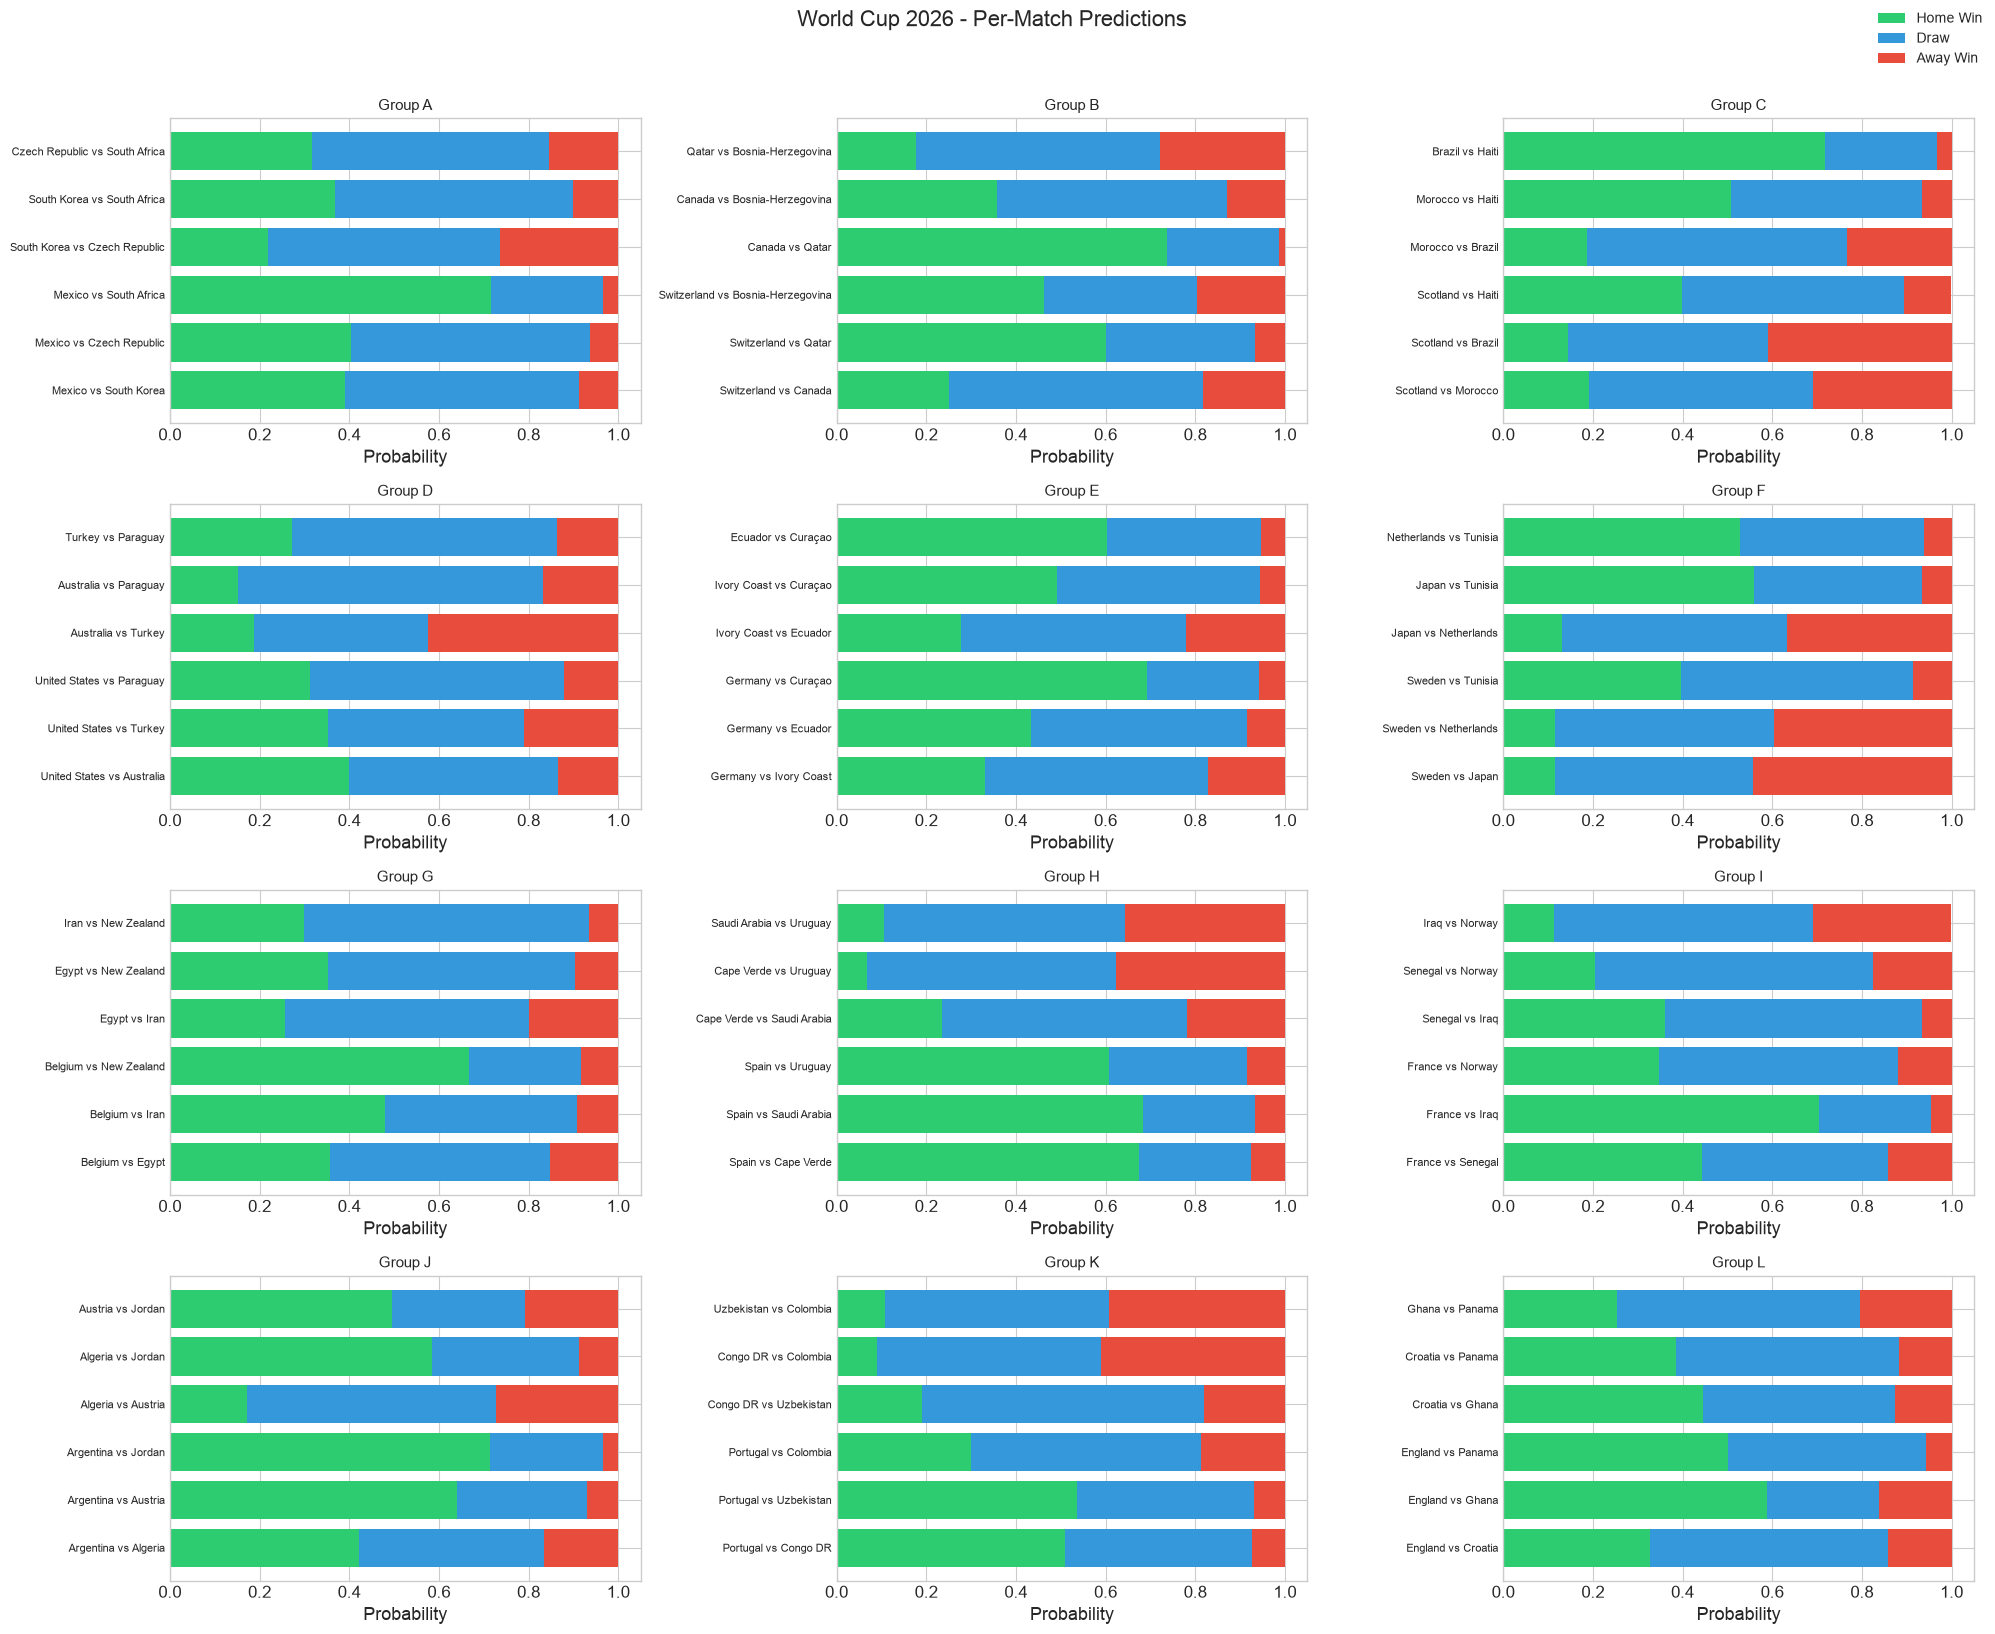

In [4]:
plot_match_predictions(match_preds, save=False)
plt.show()

## 3. Power Rankings

In [5]:
power_rankings = format_power_rankings(results)
print(power_rankings)

2026-07-01 11:40:56,310 [INFO] worldcup: Formatting power rankings...
2026-07-01 11:40:56,312 [INFO] worldcup: 
                                   WORLD CUP 2026 POWER RANKINGS                                    
Rank  Team                     Win%      Final%    SF%       QF%       Ro16%     
----------------------------------------------------------------------------------------------------
1     Mexico                   9.20      9.20      17.50     38.00     68.70     
2     Switzerland              7.80      7.80      15.20     29.90     55.00     
3     Brazil                   6.60      6.60      13.80     26.90     63.00     
4     United States            6.50      6.50      12.80     22.70     51.60     
5     France                   5.40      5.40      12.50     20.60     38.50     
6     Argentina                4.60      4.60      11.30     18.80     31.20     
7     Spain                    4.60      4.60      6.30      24.00     57.90     
8     Ivory Coast             

                                   WORLD CUP 2026 POWER RANKINGS                                    
Rank  Team                     Win%      Final%    SF%       QF%       Ro16%     
----------------------------------------------------------------------------------------------------
1     Mexico                   9.20      9.20      17.50     38.00     68.70     
2     Switzerland              7.80      7.80      15.20     29.90     55.00     
3     Brazil                   6.60      6.60      13.80     26.90     63.00     
4     United States            6.50      6.50      12.80     22.70     51.60     
5     France                   5.40      5.40      12.50     20.60     38.50     
6     Argentina                4.60      4.60      11.30     18.80     31.20     
7     Spain                    4.60      4.60      6.30      24.00     57.90     
8     Ivory Coast              4.30      4.30      6.40      12.30     19.60     
9     Germany                  4.10      4.10      8.10     

## 4. Winning Probabilities Chart

2026-07-01 11:40:56,346 [INFO] worldcup: Plotting tournament probabilities...


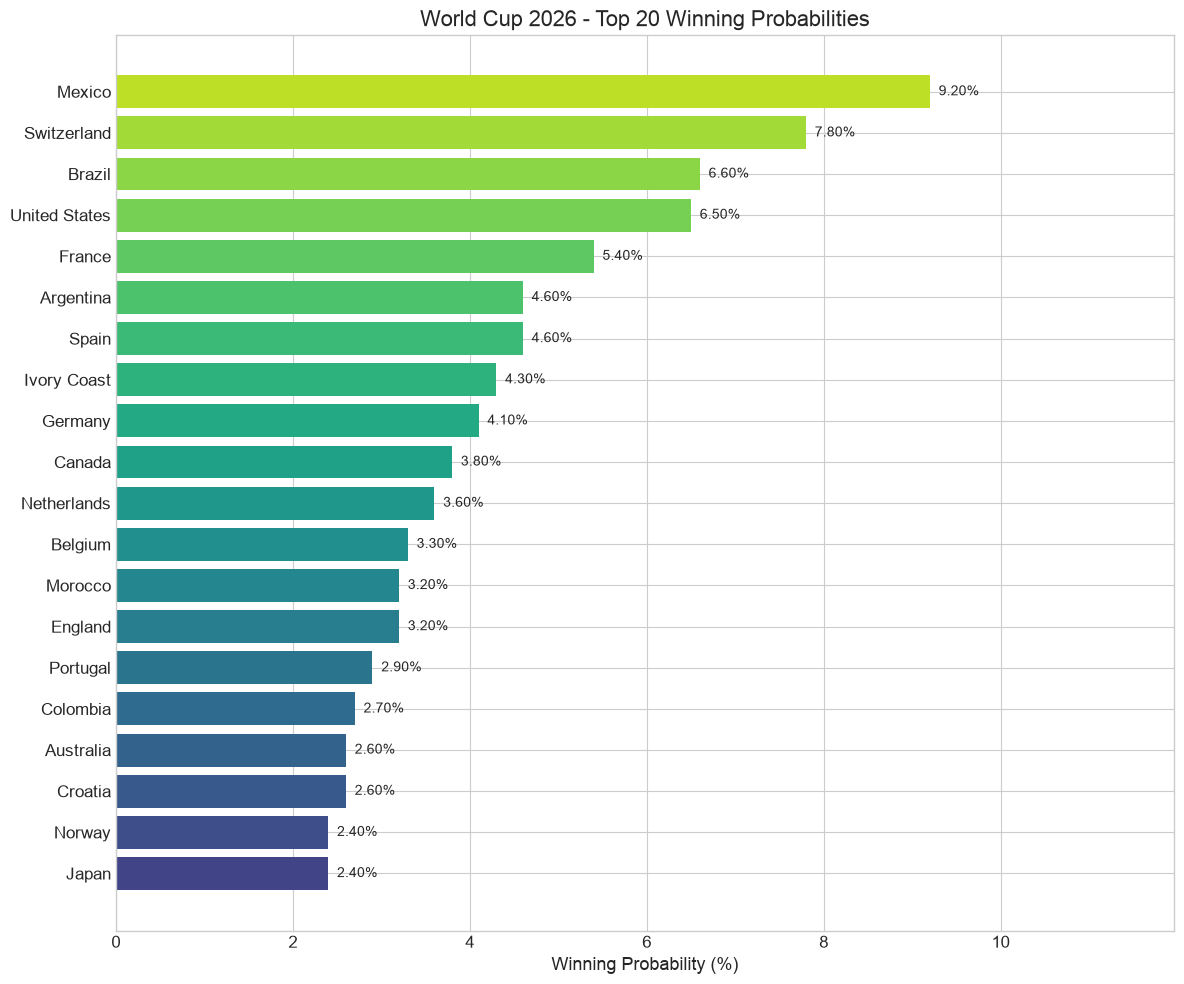

In [6]:
plot_tournament_probabilities(results, top_n=20, save=False)
plt.show()

## 5. Round Advancement Probabilities

2026-07-01 11:40:56,460 [INFO] worldcup: Plotting round advancement probabilities...


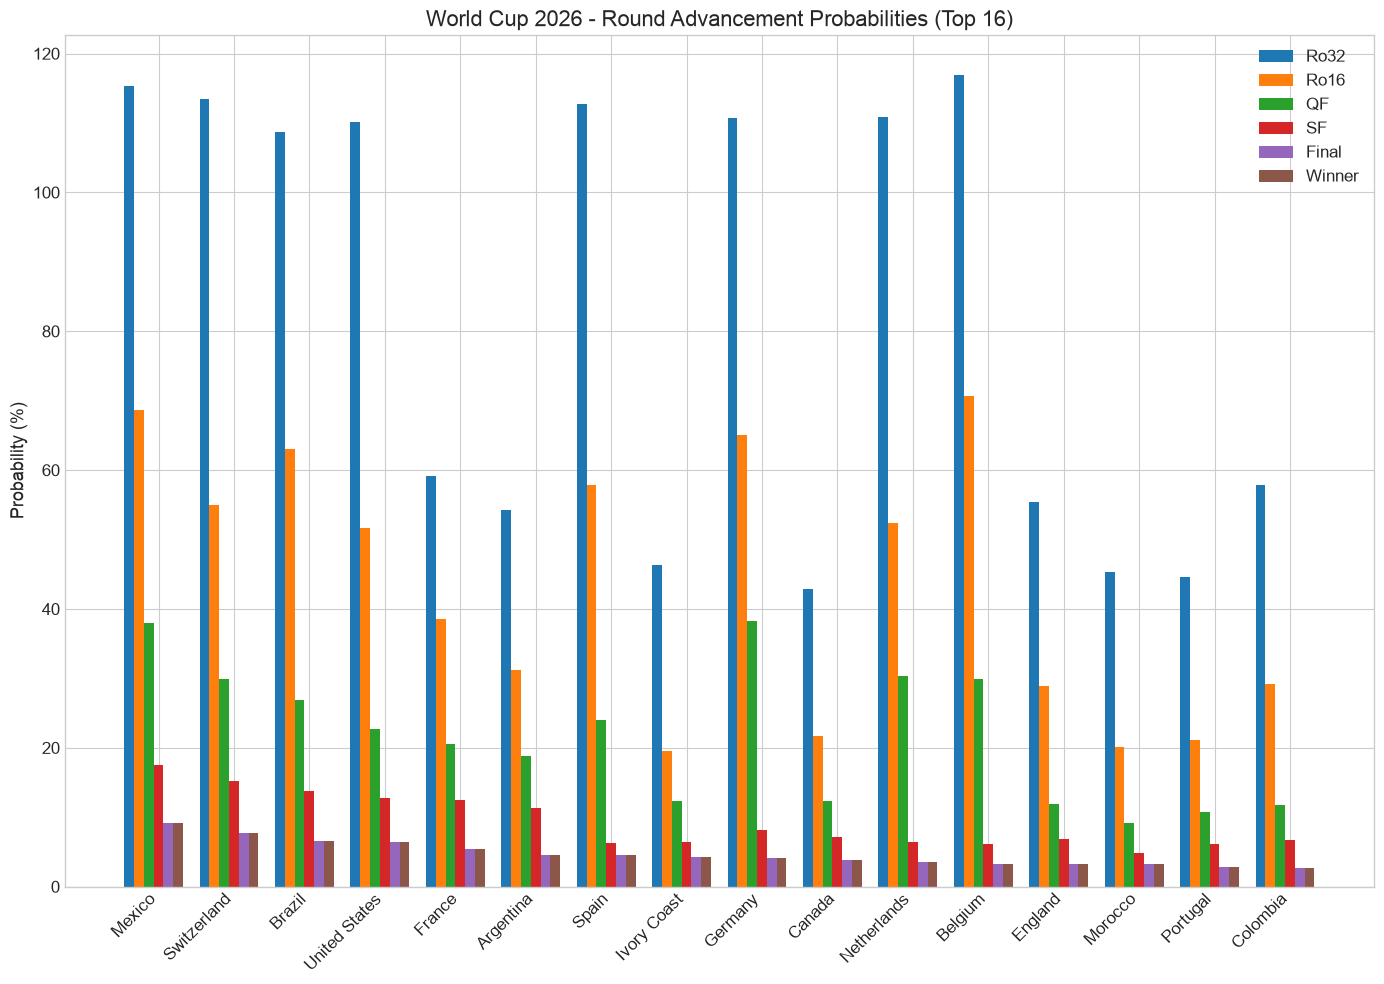

In [7]:
plot_round_probabilities(results, save=False)
plt.show()

## 6. Group Stage Probabilities

In [8]:
group_probs_path = PROCESSED_DIR / 'group_stage_probabilities.csv'
if group_probs_path.exists():
    group_probs = pd.read_csv(group_probs_path)
    group_tables = format_group_tables(group_probs)
    print(group_tables)
else:
    print('Group probabilities not found. Run simulation first.')

2026-07-01 11:40:56,596 [INFO] worldcup: Formatting group tables...
2026-07-01 11:40:56,600 [INFO] worldcup: 
                    WORLD CUP 2026 GROUP STAGE PROBABILITIES                    

Group A:
--------------------------------------------------------------------------------
Team                     1st%      2nd%      3rd%      4th%      Advance%  
--------------------------------------------------------------------------------
Mexico                   100.00    0.00      0.00      0.00      100.00    
South Africa             0.00      100.00    0.00      0.00      100.00    
South Korea              0.00      0.00      100.00    0.00      0.00      
Czech Republic           0.00      0.00      0.00      100.00    0.00      

Group B:
--------------------------------------------------------------------------------
Team                     1st%      2nd%      3rd%      4th%      Advance%  
--------------------------------------------------------------------------------
Switzerla

                    WORLD CUP 2026 GROUP STAGE PROBABILITIES                    

Group A:
--------------------------------------------------------------------------------
Team                     1st%      2nd%      3rd%      4th%      Advance%  
--------------------------------------------------------------------------------
Mexico                   100.00    0.00      0.00      0.00      100.00    
South Africa             0.00      100.00    0.00      0.00      100.00    
South Korea              0.00      0.00      100.00    0.00      0.00      
Czech Republic           0.00      0.00      0.00      100.00    0.00      

Group B:
--------------------------------------------------------------------------------
Team                     1st%      2nd%      3rd%      4th%      Advance%  
--------------------------------------------------------------------------------
Switzerland              100.00    0.00      0.00      0.00      100.00    
Canada                   0.00      100.00  

2026-07-01 11:40:56,635 [INFO] worldcup: Plotting group stage heatmaps...


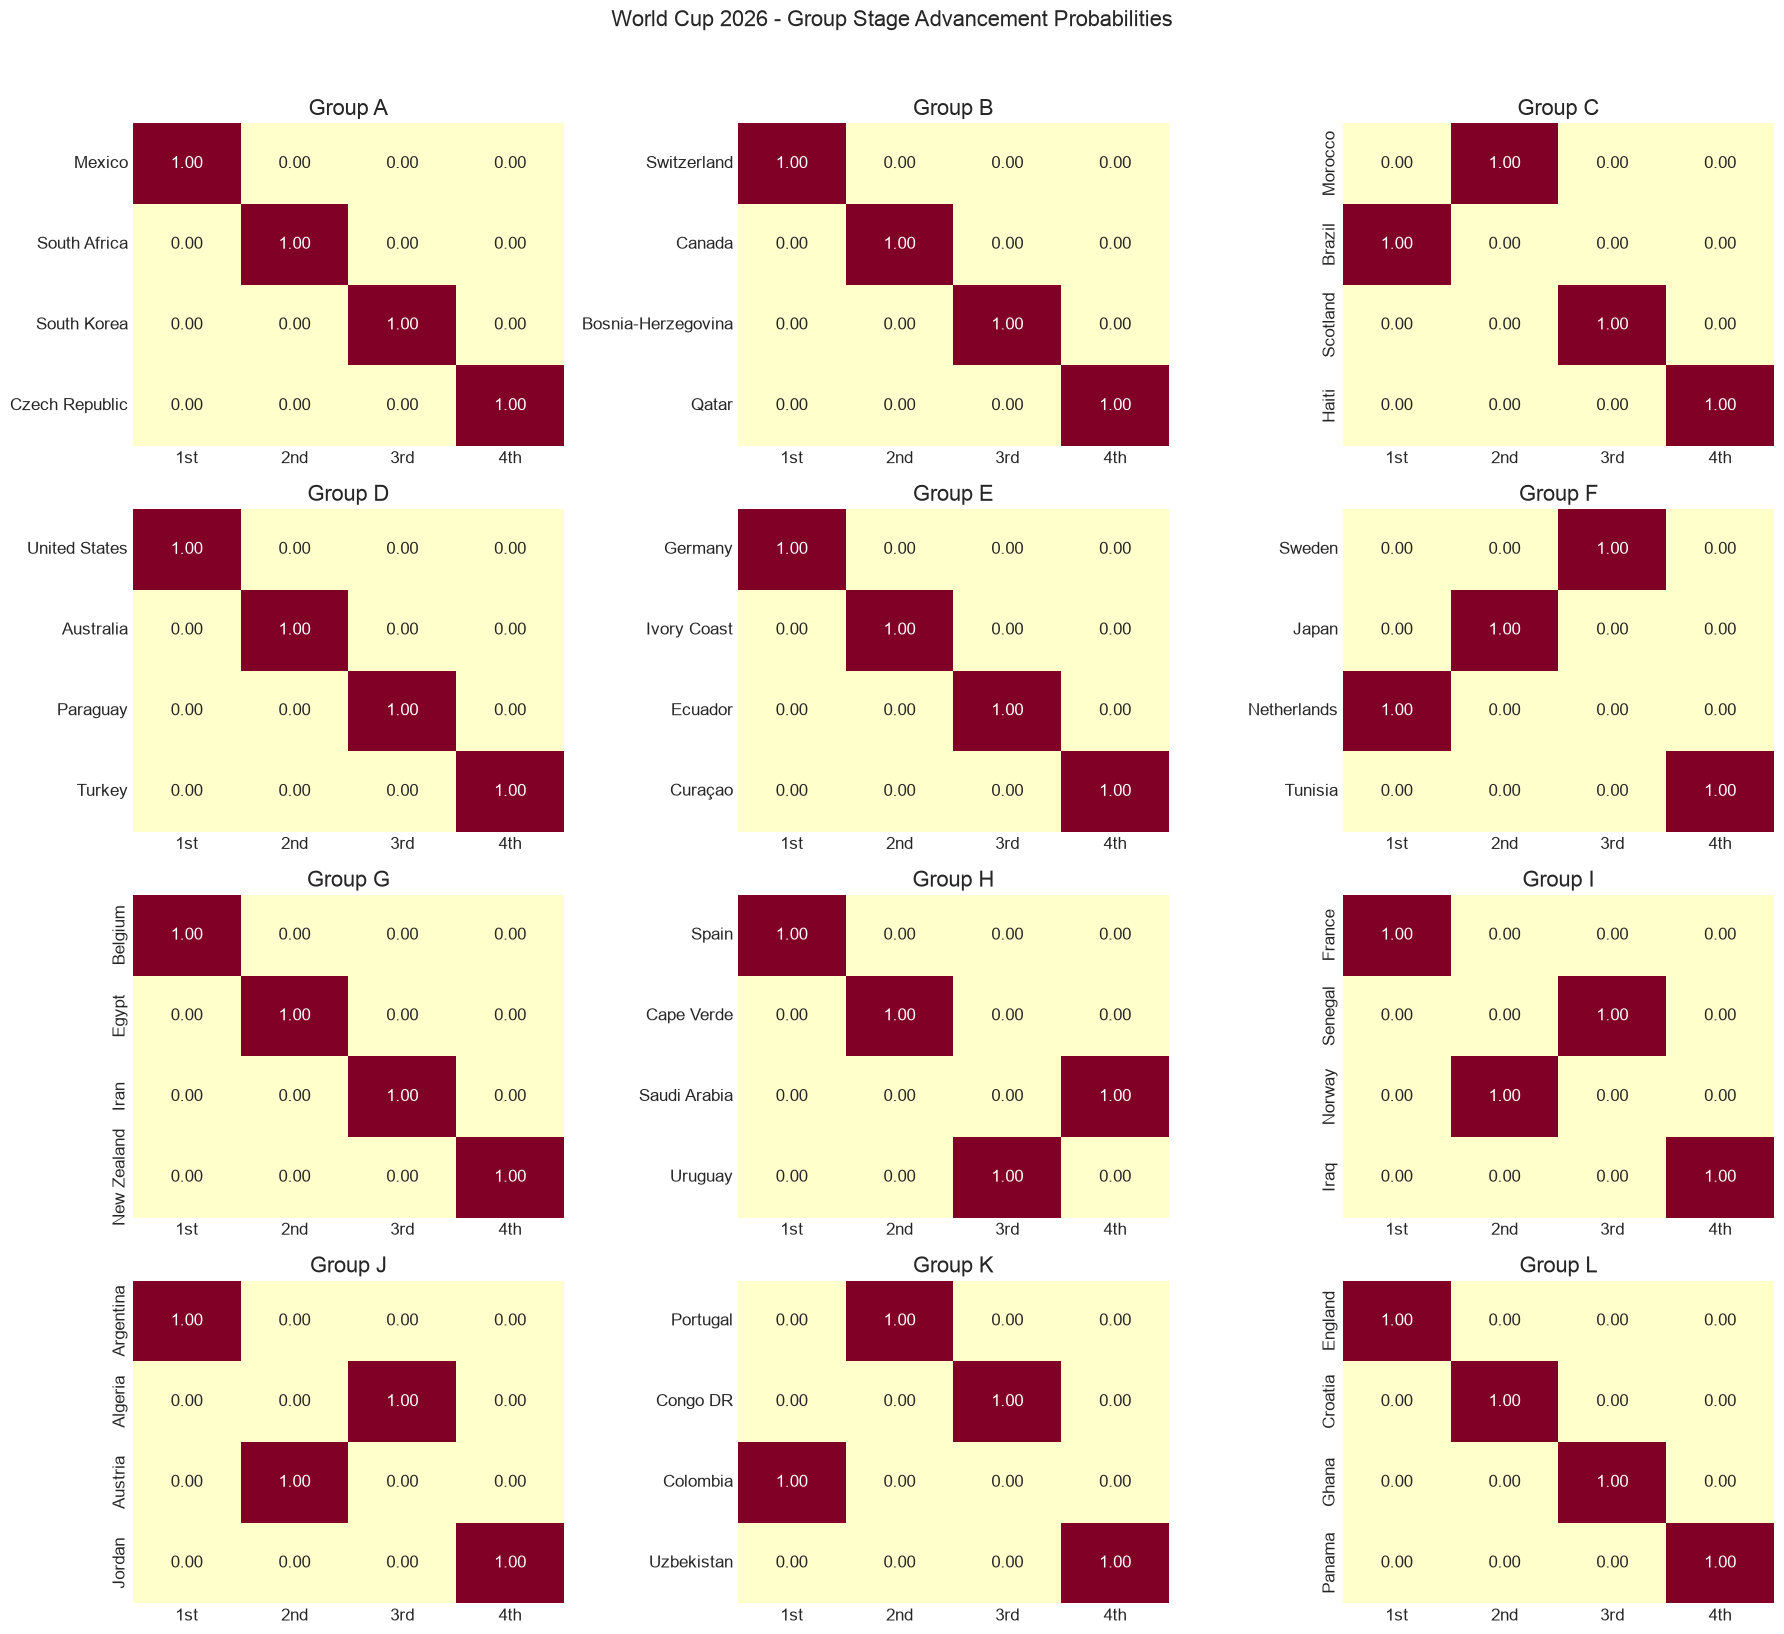

In [9]:
if group_probs_path.exists():
    plot_group_heatmaps(group_probs, save=False)
    plt.show()

## 7. Bracket Summary

In [10]:
bracket_summary = format_bracket_summary(results)
print(bracket_summary)

2026-07-01 11:40:58,066 [INFO] worldcup: Formatting bracket summary...
2026-07-01 11:40:58,067 [INFO] worldcup: 
                    WORLD CUP 2026 BRACKET SUMMARY                    
Team                     Winner    Final     SF        QF        R16       
----------------------------------------------------------------------
Mexico                   9.20      9.20      17.50     38.00     68.70     
Switzerland              7.80      7.80      15.20     29.90     55.00     
Brazil                   6.60      6.60      13.80     26.90     63.00     
United States            6.50      6.50      12.80     22.70     51.60     
France                   5.40      5.40      12.50     20.60     38.50     
Argentina                4.60      4.60      11.30     18.80     31.20     
Spain                    4.60      4.60      6.30      24.00     57.90     
Ivory Coast              4.30      4.30      6.40      12.30     19.60     
Germany                  4.10      4.10      8.10      38.20 

                    WORLD CUP 2026 BRACKET SUMMARY                    
Team                     Winner    Final     SF        QF        R16       
----------------------------------------------------------------------
Mexico                   9.20      9.20      17.50     38.00     68.70     
Switzerland              7.80      7.80      15.20     29.90     55.00     
Brazil                   6.60      6.60      13.80     26.90     63.00     
United States            6.50      6.50      12.80     22.70     51.60     
France                   5.40      5.40      12.50     20.60     38.50     
Argentina                4.60      4.60      11.30     18.80     31.20     
Spain                    4.60      4.60      6.30      24.00     57.90     
Ivory Coast              4.30      4.30      6.40      12.30     19.60     
Germany                  4.10      4.10      8.10      38.20     65.10     
Canada                   3.80      3.80      7.20      12.40     21.70     
Netherlands           

## 8. What-If Scenarios

In [11]:
top_teams = results.head(10)['team'].tolist()
print('Top 10 teams by winning probability:')
for i, team in enumerate(top_teams, 1):
    prob = results[results['team'] == team]['prob_winner'].values[0]
    print(f'  {i}. {team}: {prob:.4f}')

Top 10 teams by winning probability:
  1. Mexico: 0.0920
  2. Switzerland: 0.0780
  3. Brazil: 0.0660
  4. United States: 0.0650
  5. France: 0.0540
  6. Argentina: 0.0460
  7. Spain: 0.0460
  8. Ivory Coast: 0.0430
  9. Germany: 0.0410
  10. Canada: 0.0380


## 9. Key Insights & Analysis

In [12]:
from src.visualization.insights import (
    compute_confederation_stats,
    compute_host_nation_impact,
    compute_draw_analysis,
    compute_dark_horses,
    compute_surprise_matches,
    compute_most_competitive_groups,
    compare_with_odds,
)

group_probs = pd.read_csv(PROCESSED_DIR / 'group_stage_probabilities.csv')

### 9a. Model Performance Summary

In [13]:
eval_path = PROCESSED_DIR / 'evaluation' / 'model_comparison.csv'
if eval_path.exists():
    eval_df = pd.read_csv(eval_path)
    print('Model Performance on Test Set:')
    print(eval_df.to_string(index=False))
    best = eval_df.iloc[0]
    print(f'\nBest model: {best["Model"]} — Accuracy: {best["Accuracy"]:.4f}, Log Loss: {best["Log Loss"]:.4f}')
else:
    print('Model evaluation not found. Run training pipeline first.')

Model Performance on Test Set:
             Model  Accuracy  Log Loss  Brier (home_win)  Brier (draw)  Brier (away_win)  Avg Brier
      BestEnsemble  0.614812  0.835245          0.174125      0.172337          0.143577   0.163346
      Randomforest  0.593260  0.857292          0.181104      0.176513          0.146663   0.168094
Logisticregression  0.579154  0.873891          0.188889      0.180533          0.146202   0.171874
           Xgboost  0.504702  0.955328          0.193890      0.227067          0.160220   0.193726
         Neuralnet  0.358934  1.732182          0.304390      0.426819          0.221698   0.317636

Best model: BestEnsemble — Accuracy: 0.6148, Log Loss: 0.8352


### 9b. Confederation Analysis

In [14]:
confed_stats = compute_confederation_stats(results)
print('Confederation Strength Overview:')
print(confed_stats.to_string(index=False))
print(f'\nKey takeaway: {confed_stats.iloc[0]["confederation"]} teams average the highest win probability ({confed_stats.iloc[0]["avg_prob_winner"]:.1f}%),')
print(f'led by {confed_stats.iloc[0]["best_team"]} ({confed_stats.iloc[0]["best_team_win_pct"]:.1f}%).')

Confederation Strength Overview:
confederation  n_teams  avg_prob_winner  avg_prob_advance_ro16  avg_prob_qf   best_team  best_team_win_pct
     CONCACAF        6         3.250000              23.666667    12.183333      Mexico                9.2
         UEFA       16         2.700000              30.406250    15.400000 Switzerland                7.8
     CONMEBOL        6         2.683333              28.700000    13.400000      Brazil                6.6
          CAF       10         1.620000              16.060000     7.950000 Ivory Coast                4.3
          AFC        9         0.555556               4.300000     2.288889   Australia                2.6
          OFC        1         0.000000               0.000000     0.000000 New Zealand                0.0

Key takeaway: CONCACAF teams average the highest win probability (3.2%),
led by Mexico (9.2%).


### 9c. Host Nation Advantage

In [15]:
host_impact = compute_host_nation_impact(results, match_preds)
print('Host Nation Performance:')
for host, data in host_impact.items():
    print(f'  {host}:')
    print(f'    Win: {data["prob_winner"]:.1f}% | Final: {data["prob_final"]:.1f}% | SF: {data["prob_sf"]:.1f}% | QF: {data["prob_qf"]:.1f}% | Ro16: {data["prob_ro16"]:.1f}%')
    print(f'    Home matches: predicted {data["home_matches_predicted_wins"]}/{data["home_matches_total"]} wins (avg home win prob: {data["avg_home_win_pct"]:.1f}%)')

total_host_win = sum(d['prob_winner'] for d in host_impact.values())
print(f'\nCombined host win probability: {total_host_win:.1f}% (hosts hold {total_host_win:.1f}% of total win probability across 48 teams)')

Host Nation Performance:
  United States:
    Win: 6.5% | Final: 6.5% | SF: 12.8% | QF: 22.7% | Ro16: 51.6%
    Home matches: predicted 0/3 wins (avg home win prob: 35.5%)
  Canada:
    Win: 3.8% | Final: 3.8% | SF: 7.2% | QF: 12.4% | Ro16: 21.7%
    Home matches: predicted 1/2 wins (avg home win prob: 54.8%)
  Mexico:
    Win: 9.2% | Final: 9.2% | SF: 17.5% | QF: 38.0% | Ro16: 68.7%
    Home matches: predicted 1/3 wins (avg home win prob: 50.3%)

Combined host win probability: 19.5% (hosts hold 19.5% of total win probability across 48 teams)


### 9d. Draw Prediction Analysis

In [16]:
draw_info = compute_draw_analysis(match_preds)
print(f'Draw Prediction Summary:')
print(f'  Predicted draws: {draw_info["predicted_draws"]}/{draw_info["total_matches"]} ({draw_info["draw_rate"]:.1f}%)')
print(f'  Predicted home wins: {draw_info["predicted_home_wins"]} ({draw_info["predicted_home_wins"]/draw_info["total_matches"]*100:.1f}%)')
print(f'  Predicted away wins: {draw_info["predicted_away_wins"]} ({draw_info["predicted_away_wins"]/draw_info["total_matches"]*100:.1f}%)')
print(f'  Average draw probability: {draw_info["avg_draw_prob"]:.1f}%')
print(f'  Range: {draw_info["min_draw_prob"]:.1f}% — {draw_info["max_draw_prob"]:.1f}%')
print(f'\nTop 10 most likely draws:')
print(draw_info['high_draw_matches'].to_string(index=False))

Draw Prediction Summary:
  Predicted draws: 43/72 (59.7%)
  Predicted home wins: 28 (38.9%)
  Predicted away wins: 1 (1.4%)
  Average draw probability: 45.3%
  Range: 25.0% — 68.0%

Top 10 most likely draws:
group     home_team   away_team  prob_draw
    D     Australia    Paraguay     0.6798
    G          Iran New Zealand     0.6363
    K      Congo DR  Uzbekistan     0.6293
    I       Senegal      Norway     0.6185
    D        Turkey    Paraguay     0.5891
    C       Morocco      Brazil     0.5819
    I          Iraq      Norway     0.5783
    I       Senegal        Iraq     0.5733
    D United States    Paraguay     0.5681
    B   Switzerland      Canada     0.5667


### 9e. Dark Horses & Underdogs

In [17]:
dark_horses = compute_dark_horses(results, group_probs)
if not dark_horses.empty:
    print('Top 10 Non-UEFA/CONMEBOL Teams (Dark Horses):')
    cols = ['team', 'prob_winner', 'prob_advance', 'prob_1st_in_group']
    display_cols = {c: c.replace('_', ' ').title() for c in cols}
    print(dark_horses[cols].rename(columns=display_cols).to_string(index=False))
    print(f'\nKey insight: Mexico leads all dark horses at {dark_horses.iloc[0]["prob_winner"]*100:.1f}%,')
    print(f'benefiting from host advantage and a {dark_horses.iloc[0]["prob_advance"]:.0f}% group advancement probability.')

Top 10 Non-UEFA/CONMEBOL Teams (Dark Horses):
         Team  Prob Winner  Prob Advance  Prob 1St In Group
       Mexico        0.092         100.0              100.0
United States        0.065         100.0              100.0
  Ivory Coast        0.043         100.0                0.0
       Canada        0.038         100.0                0.0
      Morocco        0.032         100.0                0.0
    Australia        0.026         100.0                0.0
        Japan        0.024         100.0                0.0
     Congo DR        0.023         100.0                0.0
 South Africa        0.021         100.0                0.0
   Cape Verde        0.016         100.0                0.0

Key insight: Mexico leads all dark horses at 9.2%,
benefiting from host advantage and a 100% group advancement probability.


### 9f. Most Competitive Groups

In [18]:
comp_groups = compute_most_competitive_groups(group_probs)
print('Group Competitiveness (sorted by tightness):')
print(comp_groups.to_string(index=False))
tight = comp_groups[comp_groups['is_tight']]
if not tight.empty:
    print(f'\nTightest group: Group {tight.iloc[0]["group"]} (advance spread: {tight.iloc[0]["advance_spread"]:.1f}%)')
    print(f'  Most likely 1st: {tight.iloc[0]["most_likely_1st"]} ({tight.iloc[0]["most_likely_1st_pct"]:.1f}%)')
else:
    least_spread = comp_groups.iloc[0]
    print(f'\nTightest group: Group {least_spread["group"]} (advance spread: {least_spread["advance_spread"]:.1f}%)')

Group Competitiveness (sorted by tightness):
group  advance_spread  avg_advance_pct most_likely_1st  most_likely_1st_pct  is_tight
    A           100.0             50.0          Mexico                100.0     False
    B           100.0             75.0     Switzerland                100.0     False
    C           100.0             50.0          Brazil                100.0     False
    D           100.0             75.0   United States                100.0     False
    E           100.0             75.0         Germany                100.0     False
    F           100.0             75.0     Netherlands                100.0     False
    G           100.0             50.0         Belgium                100.0     False
    H           100.0             50.0           Spain                100.0     False
    I           100.0             75.0          France                100.0     False
    J           100.0             75.0       Argentina                100.0     False
    K    

### 9g. Surprise Predictions & Upset Alerts

In [19]:
surprises = compute_surprise_matches(match_preds)
if not surprises.empty:
    print('Top 10 Most Surprising Predictions (away wins & draws that defy home advantage):')
    print(surprises.to_string(index=False))
    top = surprises.iloc[0]
    print(f'\nBiggest upset alert: {top["home_team"]} vs {top["away_team"]} — model predicts {top["prediction"]}')
    print(f'  Away win prob: {top["prob_away_win"]*100:.1f}%, Home win prob: {top["prob_home_win"]*100:.1f}%')

Top 10 Most Surprising Predictions (away wins & draws that defy home advantage):
group   home_team    away_team  prob_home_win  prob_draw  prob_away_win prediction  surprise_score
    D   Australia     Paraguay         0.1523     0.6798         0.1679       draw          0.5119
    K    Congo DR   Uzbekistan         0.1898     0.6293         0.1809       draw          0.4395
    I     Senegal       Norway         0.2058     0.6185         0.1757       draw          0.4127
    C     Morocco       Brazil         0.1860     0.5819         0.2321       draw          0.3498
    G        Iran  New Zealand         0.2983     0.6363         0.0654       draw          0.3380
    B Switzerland       Canada         0.2503     0.5667         0.1830       draw          0.3164
    D      Turkey     Paraguay         0.2735     0.5891         0.1374       draw          0.3156
    H  Cape Verde Saudi Arabia         0.2354     0.5455         0.2191       draw          0.3101
    L       Ghana       Pana

### 9h. Model vs Betting Odds Comparison

In [20]:
odds_comparison = compare_with_odds(results)
if odds_comparison is not None:
    print('Model vs Betting Odds (FIFA ranking fallback):')
    print(odds_comparison.to_string(index=False))
    over = odds_comparison[odds_comparison['diff_pct'] > 0]
    under = odds_comparison[odds_comparison['diff_pct'] < 0]
    if not over.empty:
        print(f'\nModel overvalues vs odds: {", ".join(over["team"].tolist())}')
    if not under.empty:
        print(f'Model undervalues vs odds: {", ".join(under["team"].tolist())}')
else:
    print('Betting odds data not available. Set ODDS_API_KEY and re-run data pipeline.')

Model vs Betting Odds (FIFA ranking fallback):
         team  model_prob  odds_prob  diff_pct
       Mexico       0.092   0.036289  5.571082
  Switzerland       0.078   0.030097  4.790318
       Brazil       0.066   0.053700  1.229965
United States       0.065   0.033457  3.154272
       France       0.054   0.090706 -3.670564
    Argentina       0.046   0.093735 -4.773480
        Spain       0.046   0.092543 -4.654264
      Germany       0.041   0.046200 -0.519953
  Netherlands       0.036   0.050500 -1.449981
      Belgium       0.033   0.047719 -1.471852
      Morocco       0.032   0.050888 -1.888761
      England       0.032   0.073275 -4.127500
     Portugal       0.029   0.054237 -2.523734
     Colombia       0.027   0.038316 -1.131608
      Croatia       0.026   0.041615 -1.561537
        Japan       0.024   0.031881 -0.788130
      Senegal       0.000   0.035676 -3.567569
      Uruguay       0.000   0.033767 -3.376651
         Iran       0.000   0.025842 -2.584248

Model overva

### 9i. Simulation Summary

In [21]:
print('=' * 80)
print(f'{"WORLD CUP 2026 PREDICTION SUMMARY":^80}')
print('=' * 80)
print(f'Simulations run: {n_sim:,}')
print(f'Model: XGBoost (fast simulation mode)')
print(f'Matches predicted: {len(match_preds)} group stage')
print(f'')
print(f'Winner probabilities: Top 5')
for i, row in results.head(5).iterrows():
    print(f'  {i+1}. {row["team"]}: {row["prob_winner"]*100:.1f}%')
print(f'')
print(f'Host nations (combined): {sum(host_impact[h]["prob_winner"] for h in host_impact):.1f}% win probability')
print(f'Predicted draw rate: {draw_info["draw_rate"]:.1f}% ({draw_info["predicted_draws"]}/{draw_info["total_matches"]} matches)')
print(f'Most competitive group: Group {comp_groups.iloc[0]["group"]} (spread: {comp_groups.iloc[0]["advance_spread"]:.1f}%)')
if not surprises.empty:
    top_s = surprises.iloc[0]
    print(f'Biggest upset alert: {top_s["away_team"]} over {top_s["home_team"]} ({top_s["prob_away_win"]*100:.1f}%)')
print('=' * 80)

                       WORLD CUP 2026 PREDICTION SUMMARY                        
Simulations run: 1,000
Model: XGBoost (fast simulation mode)
Matches predicted: 72 group stage

Winner probabilities: Top 5
  1. Mexico: 9.2%
  2. Switzerland: 7.8%
  3. Brazil: 6.6%
  4. United States: 6.5%
  5. France: 5.4%

Host nations (combined): 19.5% win probability
Predicted draw rate: 59.7% (43/72 matches)
Most competitive group: Group A (spread: 100.0%)
Biggest upset alert: Paraguay over Australia (16.8%)
